In [5]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from scipy.special import expit as sigmoid
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from numpy.random import default_rng
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (9,6)
# file path
PATH = "Election Results 1856-2024.xlsx"

In [3]:
df_raw = pd.read_excel(PATH, header=1)
print("Columns list:", df_raw.columns.tolist())

# tag changing
rename_map = {
    "Year": "pres_year",
    "Democrat PV": "pres_dem_pv",
    "Republican PV": "pres_rep_pv",
    "Democrat PV (Two-Party)": "pres_dem_pv2p",
    "Republican PV (Two Party)": "pres_rep_pv2p",
    "Democrat EV": "pres_dem_ev",
    "Republican EV": "pres_rep_ev",
    "Democrat EV Percentage": "pres_dem_ev_pct",
    "Republican EV Percentage": "pres_rep_ev_pct",
    "Unnamed: 9": "empty_9",
    "Year.1": "house_year", # .1 is for duplicates, in the sheet it's just year
    "Democrat PV.1": "house_dem_pv",
    "Republican PV.1": "house_rep_pv",
    "Democrat PV (Two-Party).1": "house_dem_pv2p",
    "Republican PV (Two Party).1": "house_rep_pv2p",
    "Democrat Seats": "house_dem_seats",
    "Republican Seats": "house_rep_seats",
    "Democrat Seats Percentage": "house_dem_seat_pct",
    "Republican Seats Percentage": "house_rep_seat_pct"
}
df = df_raw.rename(columns=rename_map)

# Working with Democratic data (I did normalization in the sheet, so Republican data is always 1-Dem therefore unneeded)
df["pres_pv_share"] = pd.to_numeric(df.get("pres_dem_pv2p"), errors="coerce")
df["house_pv_share"] = pd.to_numeric(df.get("house_dem_pv2p"), errors="coerce")
df["pres_ev_share"] = pd.to_numeric(df["pres_dem_ev_pct"], errors="coerce")
df["house_seat_share"] = pd.to_numeric(df["house_dem_seat_pct"], errors="coerce")
    
# finalizing data frame by adding binary variable (win or lose)
df_pres = df[["pres_year", "pres_pv_share", "pres_ev_share"]].dropna().copy()
df_pres = df_pres.astype({"pres_year": float, "pres_pv_share": float, "pres_ev_share": float})
df_pres["win"] = (df_pres["pres_ev_share"] > 0.5).astype(int)
df_house = df[["house_year", "house_pv_share", "house_seat_share"]].dropna().copy()
df_house = df_house.astype({"house_year": float, "house_pv_share": float, "house_seat_share": float})
df_house["win"] = (df_house["house_seat_share"] > 0.5).astype(int)

display(df_pres.head())
display(df_house.head())

Columns list: ['Year', 'Democrat PV', 'Republican PV', 'Democrat PV (Two-Party)', 'Republican PV (Two Party)', 'Democrat EV', 'Republican EV', 'Democrat EV Percentage', 'Republican EV Percentage', 'Unnamed: 9', 'Year.1', 'Democrat PV.1', 'Republican PV.1', 'Democrat PV (Two-Party).1', 'Republican PV (Two Party).1', 'Democrat Seats', 'Republican Seats', 'Democrat Seats Percentage', 'Republican Seats Percentage']


,pres_year,pres_pv_share,pres_ev_share,win
0,1856.0,0.577806,0.604167,1
1,1860.0,0.351307,0.062500,0
2,1864.0,0.449690,0.090129,0
3,1868.0,0.473400,0.272109,0
4,1872.0,0.440644,0.187500,0


,house_year,house_pv_share,house_seat_share,win
0,1856.0,0.558869,0.594595,1
1,1858.0,0.567750,0.423469,0
2,1860.0,0.458814,0.284768,0
3,1862.0,0.475738,0.426901,0
4,1864.0,0.431818,0.192308,0


Pres logistic parameters (intercept, slope): [-84.68569606 166.78373525]
House logistic parameters (intercept, slope): [-39.49714677  78.50925522]


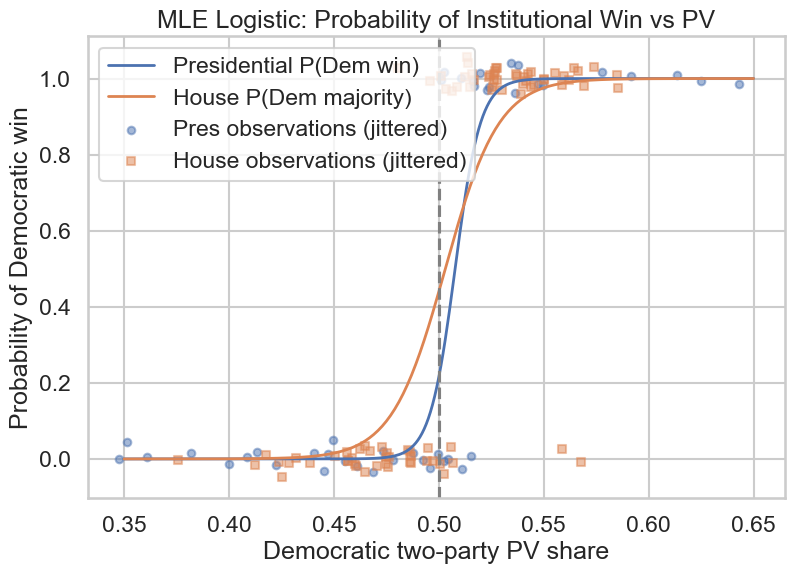

Flip points:
 - Presidential flip PV (P(win)=0.5): 0.5078
 - House flip PV: 0.5031


In [4]:
# fit logistic for Presidency and House and plot probability curves
def fit_logistic(x, y, C=1e6):
    X = x.reshape(-1,1)
    clf = LogisticRegression(C=C, solver='lbfgs', max_iter=2000)
    clf.fit(X, y)
    intercept = float(clf.intercept_[0])
    slope = float(clf.coef_[0,0])
    return np.array([intercept, slope]), clf

pres_beta, pres_model = fit_logistic(df_pres["pres_pv_share"].values, df_pres["win"].values)
house_beta, house_model = fit_logistic(df_house["house_pv_share"].values, df_house["win"].values)

print("Pres logistic parameters (intercept, slope):", pres_beta)
print("House logistic parameters (intercept, slope):", house_beta)

pv_grid = np.linspace(0.35, 0.65, 301)
pres_probs = sigmoid(pres_beta[0] + pres_beta[1] * pv_grid)
house_probs = sigmoid(house_beta[0] + house_beta[1] * pv_grid)

# This graph is largely AI-based
plt.figure(figsize=(9,6))
plt.plot(pv_grid, pres_probs, label="Presidential P(Dem win)", color='C0', lw=2)
plt.plot(pv_grid, house_probs, label="House P(Dem majority)", color='C1', lw=2)
plt.axvline(0.5, color='gray', linestyle='--')
# jitter to visualize observations around 0/1 (so they are not just on 0 or 1)
plt.scatter(df_pres["pres_pv_share"], df_pres["win"] + np.random.normal(0,0.02,len(df_pres)), alpha=0.5, s=30, label="Pres observations (jittered)")
plt.scatter(df_house["house_pv_share"], df_house["win"] + np.random.normal(0,0.02,len(df_house)), alpha=0.5, s=30, label="House observations (jittered)", marker='s')
plt.xlabel("Democratic two-party PV share")
plt.ylabel("Probability of Democratic win")
plt.title("MLE Logistic: Probability of Institutional Win vs PV")
plt.legend(); plt.grid(True); plt.show()

# Flip points
pv_flip_pres = -pres_beta[0] / pres_beta[1]
pv_flip_house = -house_beta[0] / house_beta[1]
print(f"Flip points:\n - Presidential flip PV (P(win)=0.5): {pv_flip_pres:.4f}\n - House flip PV: {pv_flip_house:.4f}")

Bootstrap shapes: (300, 2) (300, 2)


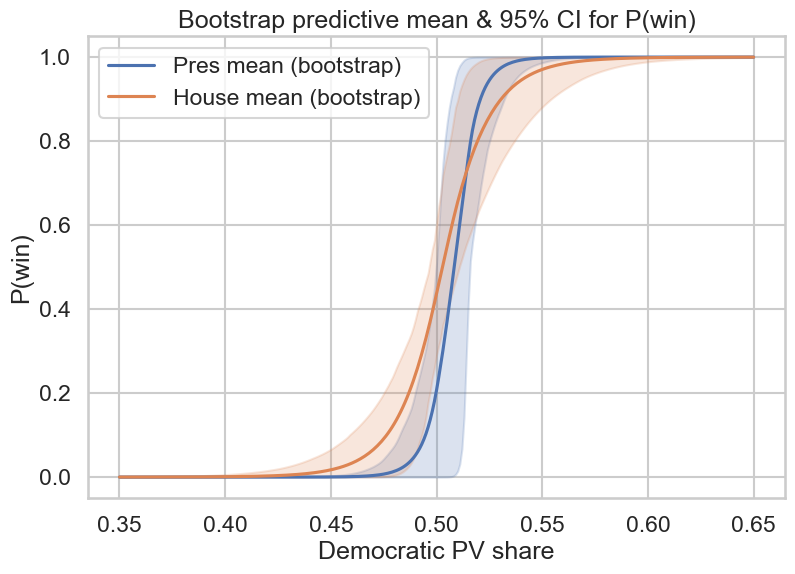

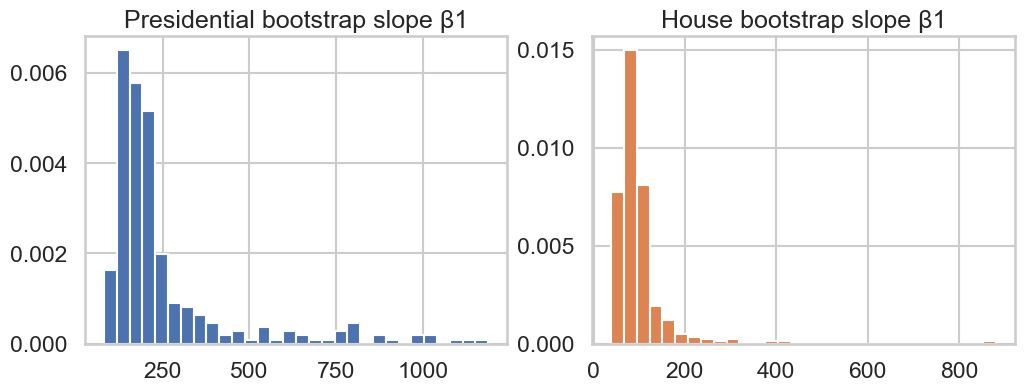

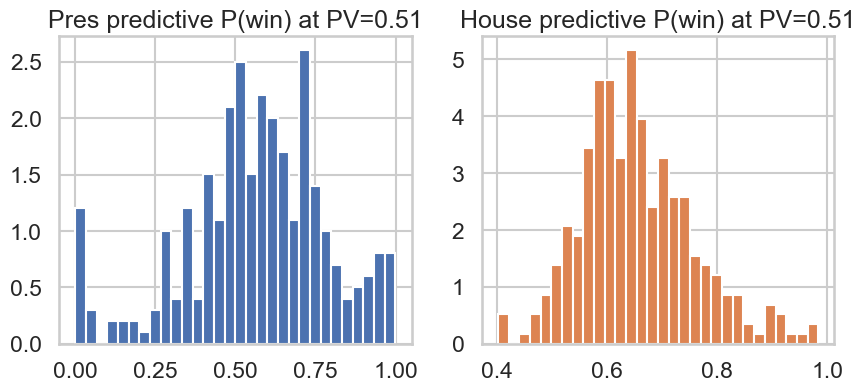

In [7]:
# Bootstrapping for the logistic regression

def bootstrap_logistic(df_in, xcol, ycol, n_success=300, seed=123, C=1e6):
    rng = default_rng(seed)
    n = len(df_in)
    betas = []
    attempts = 0
    max_attempts = n_success * 10
    while len(betas) < n_success and attempts < max_attempts:
        attempts += 1
        idx = rng.integers(0, n, n)
        sample = df_in.iloc[idx]
        y = sample[ycol].values
        # Skip resamples
        if np.unique(y).size < 2:
            continue
        X = sample[xcol].values.reshape(-1,1)
        clf = LogisticRegression(C=C, solver='lbfgs', max_iter=2000)
        try:
            clf.fit(X, y)
            betas.append((float(clf.intercept_[0]), float(clf.coef_[0,0])))
        except Exception:
            continue
    betas = np.array(betas)
    if len(betas) < n_success:
        print(f"Warning: only collected {len(betas)} successful bootstrap fits (attempted {attempts})")
    return betas

pres_betas = bootstrap_logistic(df_pres, "pres_pv_share", "win", n_success=300, seed=1)
house_betas = bootstrap_logistic(df_house, "house_pv_share", "win", n_success=300, seed=2)
print("Bootstrap shapes:", pres_betas.shape, house_betas.shape)


# Predictive bands
def bootstrap_predict_band(betas, pv_grid):
    probs = sigmoid(betas[:,0,None] + betas[:,1,None] * pv_grid[None,:])
    return probs.mean(axis=0), np.percentile(probs,2.5,axis=0), np.percentile(probs,97.5,axis=0)

pres_mean, pres_low, pres_high = bootstrap_predict_band(pres_betas, pv_grid)
house_mean, house_low, house_high = bootstrap_predict_band(house_betas, pv_grid)

plt.figure(figsize=(9,6))
plt.plot(pv_grid, pres_mean, label="Pres mean (bootstrap)", color='C0')
plt.fill_between(pv_grid, pres_low, pres_high, color='C0', alpha=0.2)
plt.plot(pv_grid, house_mean, label="House mean (bootstrap)", color='C1')
plt.fill_between(pv_grid, house_low, house_high, color='C1', alpha=0.2)
plt.xlabel("Democratic PV share"); plt.ylabel("P(win)"); plt.title("Bootstrap predictive mean & 95% CI for P(win)"); plt.legend(); plt.grid(True); plt.show()

# Show bootstrap distributions at example PV
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.hist(pres_betas[:,1], bins=30, color='C0', density=True); plt.title("Presidential bootstrap slope β1")
plt.subplot(1,2,2); plt.hist(house_betas[:,1], bins=30, color='C1', density=True); plt.title("House bootstrap slope β1")
plt.show()

pv_example = 0.51
pres_preds_at_p = sigmoid(pres_betas[:,0] + pres_betas[:,1] * pv_example)
house_preds_at_p = sigmoid(house_betas[:,0] + house_betas[:,1] * pv_example)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.hist(pres_preds_at_p, bins=30, color='C0', density=True); plt.title(f"Pres predictive P(win) at PV={pv_example}")
plt.subplot(1,2,2); plt.hist(house_preds_at_p, bins=30, color='C1', density=True); plt.title(f"House predictive P(win) at PV={pv_example}")
plt.show()

Pres Bayesian sigma(est): 0.11313384655618948 OLS intercept/slope: [-1.24135462  3.46114616]
House Bayesian sigma(est): 0.07187780238609609 OLS intercept/slope: [-0.55075113  2.11386905]


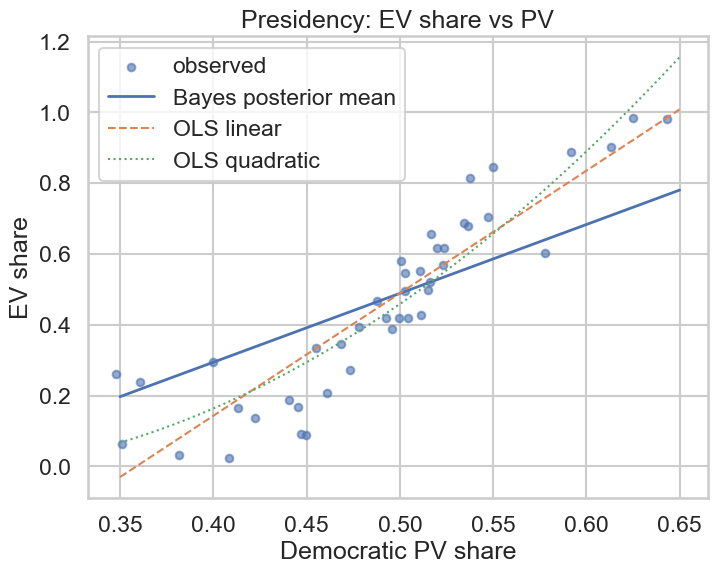

Pres RMSE linear: 0.11313384655618948
Pres RMSE quadratic: 0.10435767667775056


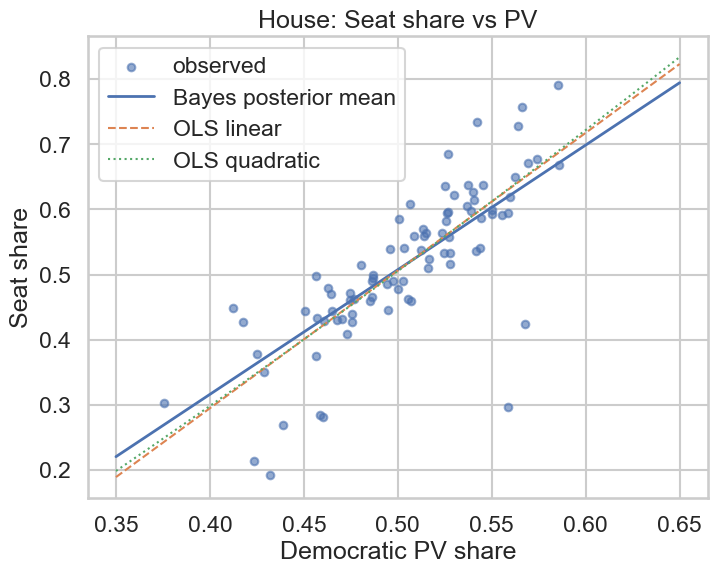

House RMSE linear: 0.0718778023860961
House RMSE quadratic: 0.07186816526515541


In [8]:
# Bayesian linear & quadratic regression for PV share -> EV share
def bayes_grid_predict(pv_vals, y_vals, alpha_grid=None, gamma_grid=None):
    pv = np.array(pv_vals); y = np.array(y_vals)
    n = len(pv)
    A = np.vstack([np.ones(n), pv]).T
    coef = np.linalg.lstsq(A, y, rcond=None)[0]
    resid = y - A.dot(coef)
    sigma = max(np.std(resid), 1e-3)
    if alpha_grid is None:
        alpha_grid = np.linspace(-0.5, 0.5, 121)
    if gamma_grid is None:
        gamma_grid = np.linspace(-2.0, 6.0, 121)
    logpost = np.empty((len(alpha_grid), len(gamma_grid)))
    for i,a in enumerate(alpha_grid):
        for j,g in enumerate(gamma_grid):
            mu = a + g * pv
            ll = -0.5 * np.sum((y - mu)**2) / sigma**2
            logpost[i,j] = ll
    logpost = logpost - np.max(logpost)
    post = np.exp(logpost)
    post = post / post.sum()
    def predict_mean(pv0):
        mu_grid = alpha_grid[:,None] + gamma_grid[None,:] * pv0
        return float((mu_grid * post).sum())
    return predict_mean, post, alpha_grid, gamma_grid, sigma, coef

# President
pv_pres = df_pres["pres_pv_share"].values; ev_pres = df_pres["pres_ev_share"].values
predict_ev_mean, post_ev, alpha_ev, gamma_ev, sigma_ev, ols_ev_coef = bayes_grid_predict(pv_pres, ev_pres)
print("Pres Bayesian sigma(est):", sigma_ev, "OLS intercept/slope:", ols_ev_coef)

# House
pv_house = df_house["house_pv_share"].values; seat_house = df_house["house_seat_share"].values
predict_seat_mean, post_seat, alpha_seat, gamma_seat, sigma_seat, ols_seat_coef = bayes_grid_predict(pv_house, seat_house)
print("House Bayesian sigma(est):", sigma_seat, "OLS intercept/slope:", ols_seat_coef)

# Bayes mean + OLS linear vs quadratic
def fit_ols_lin_quad(x,y):
    X1 = sm.add_constant(x); res1 = sm.OLS(y, X1).fit()
    X2 = sm.add_constant(np.vstack([x, x**2]).T); res2 = sm.OLS(y, X2).fit()
    return res1, res2

res1_pres, res2_pres = fit_ols_lin_quad(pv_pres, ev_pres)
pv_test = np.linspace(0.35, 0.65, 301)

# Pres
plt.figure(figsize=(8,6))
plt.scatter(pv_pres, ev_pres, s=30, alpha=0.6, label='observed')
plt.plot(pv_test, [predict_ev_mean(p) for p in pv_test], label='Bayes posterior mean', lw=2)
plt.plot(pv_test, res1_pres.predict(sm.add_constant(pv_test)), label='OLS linear', lw=1.5, ls='--')
plt.plot(pv_test, res2_pres.predict(sm.add_constant(np.vstack([pv_test, pv_test**2]).T)), label='OLS quadratic', lw=1.5, ls=':')
plt.xlabel("Democratic PV share"); plt.ylabel("EV share"); plt.title("Presidency: EV share vs PV"); plt.legend(); plt.grid(True); plt.show()

print("Pres RMSE linear:", np.sqrt(np.mean((ev_pres - res1_pres.predict(sm.add_constant(pv_pres)))**2)))
print("Pres RMSE quadratic:", np.sqrt(np.mean((ev_pres - res2_pres.predict(sm.add_constant(np.vstack([pv_pres, pv_pres**2]).T)))**2)))

# House
res1_house, res2_house = fit_ols_lin_quad(pv_house, seat_house)
plt.figure(figsize=(8,6))
plt.scatter(pv_house, seat_house, s=30, alpha=0.6, label='observed')
plt.plot(pv_test, [predict_seat_mean(p) for p in pv_test], label='Bayes posterior mean', lw=2)
plt.plot(pv_test, res1_house.predict(sm.add_constant(pv_test)), label='OLS linear', lw=1.5, ls='--')
plt.plot(pv_test, res2_house.predict(sm.add_constant(np.vstack([pv_test, pv_test**2]).T)), label='OLS quadratic', lw=1.5, ls=':')
plt.xlabel("Democratic PV share"); plt.ylabel("Seat share"); plt.title("House: Seat share vs PV"); plt.legend(); plt.grid(True); plt.show()

print("House RMSE linear:", np.sqrt(np.mean((seat_house - res1_house.predict(sm.add_constant(pv_house)))**2)))
print("House RMSE quadratic:", np.sqrt(np.mean((seat_house - res2_house.predict(sm.add_constant(np.vstack([pv_house, pv_house**2]).T)))**2)))

Per-election KL (pres): mean = 0.25026524643233206 median = 0.06296000380858632
Per-election KL (house): mean = 0.037921717765064894 median = 0.01214874277836002


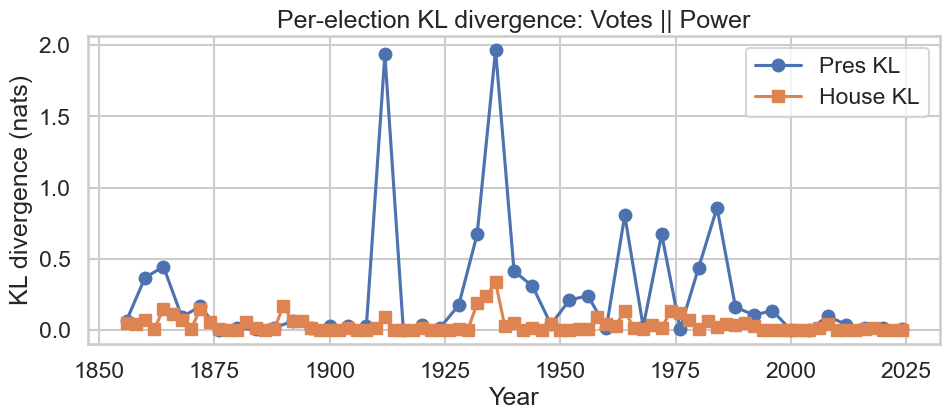

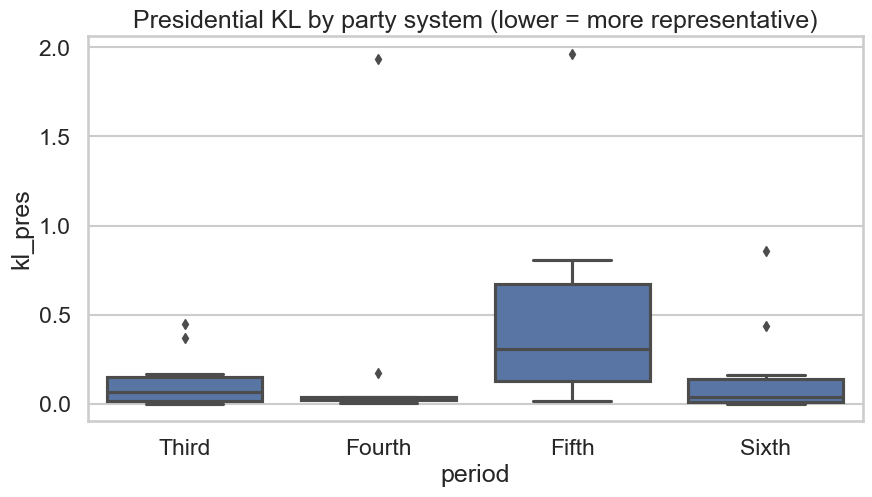

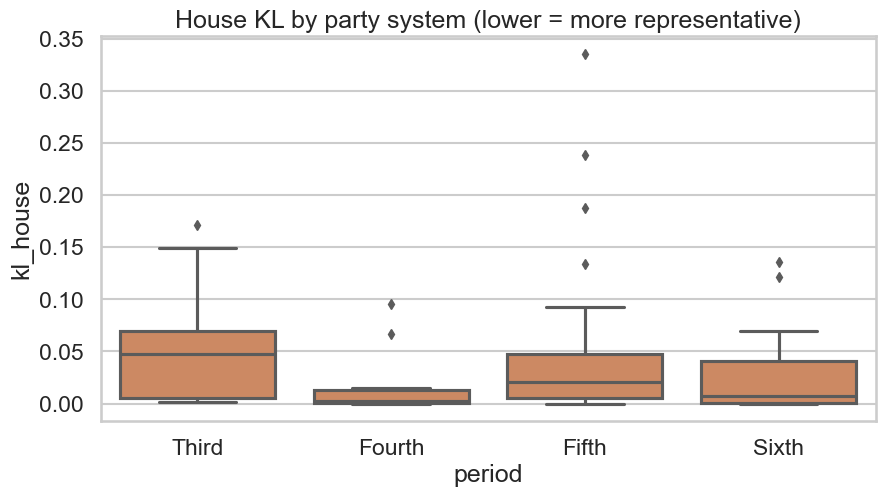

In [10]:
# Compute KL divergence between PV and result for each election
def kl_two_point(p, s, eps=1e-12):
    p = np.clip(p, eps, 1-eps)
    s = np.clip(s, eps, 1-s)
    return p * np.log(p/s) + (1-p) * np.log((1-p)/(1-s))

df_pres['kl_pres'] = df_pres.apply(lambda r: kl_two_point(r['pres_pv_share'], r['pres_ev_share']), axis=1)
df_house['kl_house'] = df_house.apply(lambda r: kl_two_point(r['house_pv_share'], r['house_seat_share']), axis=1)

# Compute summary stats
pres_kl_mean = df_pres['kl_pres'].mean(); pres_kl_median = df_pres['kl_pres'].median()
house_kl_mean = df_house['kl_house'].mean(); house_kl_median = df_house['kl_house'].median()

print("Per-election KL (pres): mean =", pres_kl_mean, "median =", pres_kl_median)
print("Per-election KL (house): mean =", house_kl_mean, "median =", house_kl_median)

# Plot by time
plt.figure(figsize=(11,4))
plt.plot(df_pres['pres_year'], df_pres['kl_pres'], marker='o', label='Pres KL', color='C0')
plt.plot(df_house['house_year'], df_house['kl_house'], marker='s', label='House KL', color='C1')
plt.xlabel("Year"); plt.ylabel("KL divergence (nats)"); plt.title("Per-election KL divergence: Votes || Power"); plt.legend(); plt.grid(True); plt.show()

# Going by party system
periods = {"Third": (1856,1892), "Fourth": (1894,1928), "Fifth": (1930,1972), "Sixth": (1974,2024)}
def assign_period(y):
    for name,(a,b) in periods.items():
        if y >= a and y <= b:
            return name
    return "Other"

df_pres['period'] = df_pres['pres_year'].apply(assign_period)
df_house['period'] = df_house['house_year'].apply(assign_period)

plt.figure(figsize=(10,5))
sns.boxplot(x='period', y='kl_pres', data=df_pres, color='C0')
plt.title("Presidential KL by party system (lower = more representative)"); plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='period', y='kl_house', data=df_house, color='C1')
plt.title("House KL by party system (lower = more representative)"); plt.show()


In [7]:
# Cell 7 — Save summary outputs (optional)
outdir = "./election_analysis_outputs"
os.makedirs(outdir, exist_ok=True)

# summary CSVs
df_pres.to_csv(os.path.join(outdir, "df_pres_with_kl.csv"), index=False)
df_house.to_csv(os.path.join(outdir, "df_house_with_kl.csv"), index=False)

# simple numeric summary
summary = {
    "pres_logistic_intercept": float(pres_beta[0]),
    "pres_logistic_slope": float(pres_beta[1]),
    "pres_flip_pv": float(-pres_beta[0]/pres_beta[1]),
    "house_logistic_intercept": float(house_beta[0]),
    "house_logistic_slope": float(house_beta[1]),
    "house_flip_pv": float(-house_beta[0]/house_beta[1]),
    "pres_kl_mean": float(pres_kl_mean),
    "pres_kl_median": float(pres_kl_median),
    "house_kl_mean": float(house_kl_mean),
    "house_kl_median": float(house_kl_median)
}
pd.DataFrame([summary]).to_csv(os.path.join(outdir, "summary_stats.csv"), index=False)

print("Saved CSVs to", outdir)

Saved CSVs to ./election_analysis_outputs
